In [2]:
from model import Model, Tokenizer, Tokenizer_linux

In [6]:
import pickle

wap_tokenizer = Tokenizer()
loaded = pickle.load(open("wap_tokenizer.pkl", "rb"))

wap_tokenizer.__dict__.update(loaded.__dict__)  

linux_tokenizer = Tokenizer_linux()
loaded = pickle.load(open("linux_tokenizer.pkl", "rb"))

linux_tokenizer.__dict__.update(loaded.__dict__)  

### Vocabulary Size Comparison

In [7]:
print("Vocabulary size of War and Peace tokenizer is: ", len(wap_tokenizer.idx_to_word))
print("Vocabulary size of Linux tokenizer is: ", len(linux_tokenizer.idx_to_word))

Vocabulary size of War and Peace tokenizer is:  20072
Vocabulary size of Linux tokenizer is:  44361


### Dataset Comparison

In [9]:
wap_corpus = open("warpeace_input.txt", "r").read()
wap_encoded_text = wap_tokenizer.encode(wap_corpus)

linux_corpus = open("linux_input.txt", "r").read()
linux_encoded_text = linux_tokenizer.encode(linux_corpus)

print("Number of tokens in warpeace: ", len(wap_encoded_text))
print("Number of tokens in linux: ", len(linux_encoded_text))

Number of tokens in warpeace:  654064
Number of tokens in linux:  1120671


### Most Frequent and Least Frequent words

In [19]:
from collections import Counter

# Count token frequencies
wap_counts = Counter(wap_encoded_text)
linux_counts = Counter(linux_encoded_text)

# Get most & least frequent tokens
wap_most_common = wap_counts.most_common(10)
wap_least_common = wap_counts.most_common()[:-11:-1]

linux_most_common = linux_counts.most_common(10)
linux_least_common = linux_counts.most_common()[:-11:-1]

# Print results
print("Top 10 most frequent tokens in War and Peace:")
for token, count in wap_most_common:
    print(f"Token {token}: {count}")

print("\n10 least frequent tokens in War and Peace:")
for token, count in wap_least_common:
    print(f"Token {token}: {count}")

print("\nTop 10 most frequent tokens in Linux corpus:")
for token, count in linux_most_common:
    print(f"Token {token}: {count}")

print("\n10 least frequent tokens in Linux corpus:")
for token, count in linux_least_common:
    print(f"Token {token}: {count}")


Top 10 most frequent tokens in War and Peace:
Token 1: 62014
Token 2: 34394
Token 3: 30590
Token 4: 22082
Token 5: 16636
Token 6: 14871
Token 7: 10464
Token 8: 9808
Token 9: 8743
Token 10: 7967

10 least frequent tokens in War and Peace:
Token 18717: 1
Token 15937: 1
Token 18530: 1
Token 16012: 1
Token 14408: 1
Token 17667: 1
Token 16189: 1
Token 18318: 1
Token 18867: 1
Token 18149: 1

Top 10 most frequent tokens in Linux corpus:
Token 1: 201920
Token 2: 77398
Token 3: 77362
Token 4: 77184
Token 5: 45848
Token 44359: 39343
Token 6: 35102
Token 7: 31591
Token 8: 27746
Token 9: 23157

10 least frequent tokens in Linux corpus:
Token 38323: 1
Token 31882: 1
Token 24413: 1
Token 22886: 1
Token 37062: 1
Token 41437: 1
Token 36903: 1
Token 29459: 1
Token 31673: 1
Token 40483: 1


In [20]:
from collections import Counter

# Count frequencies
wap_counts = Counter(wap_encoded_text)
linux_counts = Counter(linux_encoded_text)

# Get 10 most & least frequent tokens
wap_most_common = wap_counts.most_common(10)
wap_least_common = wap_counts.most_common()[:-11:-1]

linux_most_common = linux_counts.most_common(10)
linux_least_common = linux_counts.most_common()[:-11:-1]


def print_token_stats(title, token_counts, tokenizer):
    print(f"\n{title}")
    print("-" * len(title))
    for token_id, count in token_counts:
        try:
            token_str = tokenizer.decode([token_id])
        except Exception:
            token_str = "<decode_error>"
        print(f"Token ID: {token_id:<6} | Count: {count:<6} | Token: {repr(token_str)}")


# War and Peace corpus
print_token_stats("Top 10 most frequent tokens in War and Peace", wap_most_common, wap_tokenizer)
print_token_stats("10 least frequent tokens in War and Peace", wap_least_common, wap_tokenizer)

# Linux corpus
print_token_stats("Top 10 most frequent tokens in Linux corpus", linux_most_common, linux_tokenizer)
print_token_stats("10 least frequent tokens in Linux corpus", linux_least_common, linux_tokenizer)



Top 10 most frequent tokens in War and Peace
--------------------------------------------
Token ID: 1      | Count: 62014  | Token: '\n'
Token ID: 2      | Count: 34394  | Token: 'the'
Token ID: 3      | Count: 30590  | Token: '.'
Token ID: 4      | Count: 22082  | Token: 'and'
Token ID: 5      | Count: 16636  | Token: 'to'
Token ID: 6      | Count: 14871  | Token: 'of'
Token ID: 7      | Count: 10464  | Token: 'a'
Token ID: 8      | Count: 9808   | Token: 'he'
Token ID: 9      | Count: 8743   | Token: 'in'
Token ID: 10     | Count: 7967   | Token: 'his'

10 least frequent tokens in War and Peace
-----------------------------------------
Token ID: 18717  | Count: 1      | Token: 'unreal'
Token ID: 15937  | Count: 1      | Token: 'earths'
Token ID: 18530  | Count: 1      | Token: 'personalityfree'
Token ID: 16012  | Count: 1      | Token: 'immovability'
Token ID: 14408  | Count: 1      | Token: 'strengthens'
Token ID: 17667  | Count: 1      | Token: 'uninvited'
Token ID: 16189  | Count

### Loss curve Comparison

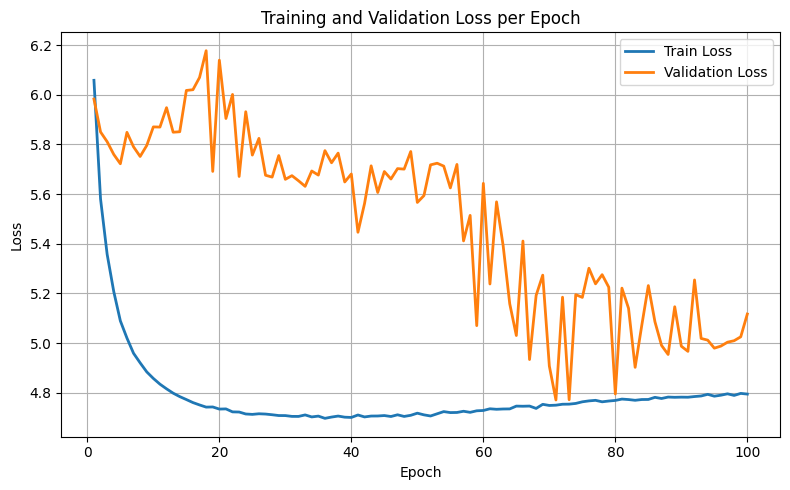

In [21]:
import numpy as np
train_loss_per_epoch = np.load("losses/wap_train.npy")
val_loss_per_epoch = np.load("losses/wap_val.npy")
import matplotlib.pyplot as plt

epochs = range(1, len(train_loss_per_epoch) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss_per_epoch, label='Train Loss', linewidth=2)
plt.plot(epochs, val_loss_per_epoch, label='Validation Loss', linewidth=2)

plt.title("Training and Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


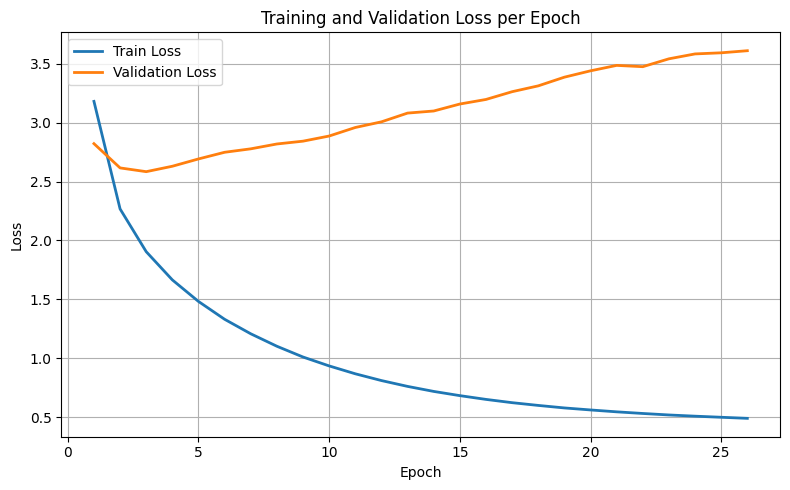

In [23]:
import numpy as np
train_loss_per_epoch = np.load("losses/linux_train.npy")
val_loss_per_epoch = np.load("losses/linux_val.npy")
import matplotlib.pyplot as plt

epochs = range(1, len(train_loss_per_epoch) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss_per_epoch, label='Train Loss', linewidth=2)
plt.plot(epochs, val_loss_per_epoch, label='Validation Loss', linewidth=2)

plt.title("Training and Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [29]:
import torch
PATH = "model_epoch50.pth"
context_size = 10
model = Model(vocab_size=len(wap_tokenizer.word_to_idx), context_size = context_size)
model.load_state_dict(torch.load(PATH, map_location=torch.device("cpu")))
vocab = list(wap_tokenizer.word_to_idx.keys())
embeddings = model.embedding.weight.data.cpu().numpy()  


In [35]:
from sklearn.manifold import TSNE

# tsne = TSNE(n_components=2, perplexity=30, n_iter=1500, random_state=42, init='pca')
# X_all_2d = tsne.fit_transform(embeddings)

selected_words = [w for group in word_groups.values() for w in group if w in wap_tokenizer.word_to_idx]
selected_idxs = [wap_tokenizer.word_to_idx[w] for w in selected_words]

X_selected_2d = X_all_2d[selected_idxs]


In [ ]:
word_groups = {
    "characters": ["pierre", "natasha", "andrei", "nikolai", "sonya", "rostov", "kutuzov", "napoleon"],
    "emotions": ["love", "fear", "joy", "sadness", "anger", "hope", "shame", "peace"],
    "warfare": ["battle", "army", "soldier", "war", "gun", "enemy", "victory", "retreat"],
    "religion": ["god", "faith", "soul", "sin", "church", "pray", "heaven"],
    "society": ["count", "princess", "duke", "servant", "emperor", "noble", "peasant"],
    "places": ["moscow", "petersburg", "smolensk", "borodino", "russia", "france"],
    "family": ["father", "mother", "brother", "sister", "wife", "husband", "child"],
    "time": ["day", "night", "morning", "evening", "year", "hour", "moment"],
    "philosophy": ["life", "death", "truth", "freedom", "destiny", "power"],
    "objects": ["horse", "letter", "table", "room", "door", "window", "house"]
}



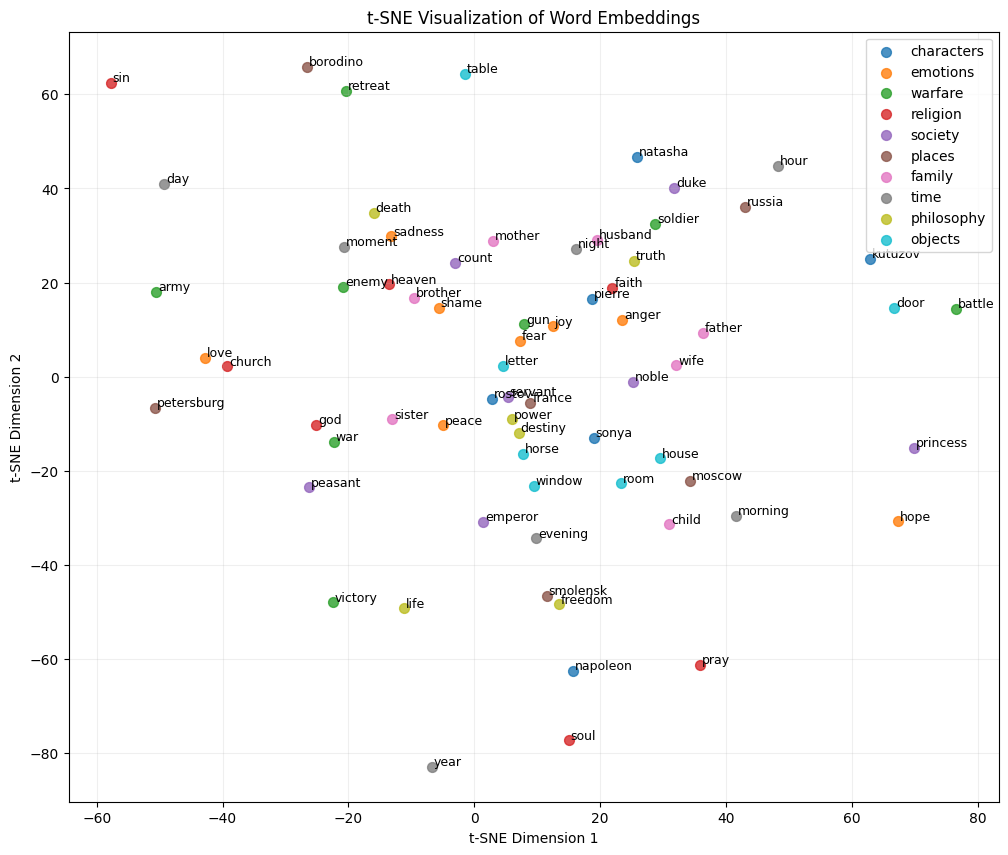

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
start = 0

for group_name, words in word_groups.items():
    words_in_group = [w for w in words if w in wap_tokenizer.word_to_idx]
    n = len(words_in_group)
    end = start + n

    plt.scatter(
        X_selected_2d[start:end, 0],
        X_selected_2d[start:end, 1],
        label=group_name,
        alpha=0.8,
        s=50
    )

    for i, word in enumerate(words_in_group):
        plt.text(
            X_selected_2d[start + i, 0] + 0.3,
            X_selected_2d[start + i, 1] + 0.3,
            word,
            fontsize=9
        )

    start = end

plt.legend()
plt.title("t-SNE Visualization of Word Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, alpha=0.2)
plt.show()


In [39]:
import torch
PATH = "model_epoch50_2.pth"
context_size = 10
model = Model(vocab_size=len(linux_tokenizer.word_to_idx)+10, context_size = context_size)
model.load_state_dict(torch.load(PATH, map_location=torch.device("cpu")))
vocab = list(linux_tokenizer.word_to_idx.keys())
embeddings = model.embedding.weight.data.cpu().numpy()  


In [40]:

word_groups = {
    "system_calls": ["open", "close", "read", "write", "fork", "exec", "wait", "exit"],
    "memory": ["malloc", "calloc", "free", "realloc", "memcpy", "memset", "strcpy"],
    "errors": ["errno", "eio", "eperm", "efault", "esrch", "eagain", "enfile"],
    "kernel": ["module_init", "module_exit", "__init", "__exit", "kernel_thread", "kthread_run"],
    "file_ops": ["open", "fopen", "fclose", "fread", "fwrite", "fprintf", "printf"],
    "networking": ["socket", "bind", "listen", "accept", "connect", "recv", "send"],
    "control_flow": ["if", "else", "for", "while", "switch", "return", "goto"],
    "variables": ["int", "char", "float", "double", "struct", "void", "typedef"],
    "boolean": ["true", "false", "0", "1", "null", "nullptr"],
    "filesystem": ["mount", "umount", "inode", "dentry", "path", "file", "fs"]
}

selected_words = [w for group in word_groups.values() for w in group if w in linux_tokenizer.word_to_idx]
selected_idxs = [linux_tokenizer.word_to_idx[w] for w in selected_words]

X_selected = embeddings[selected_idxs]


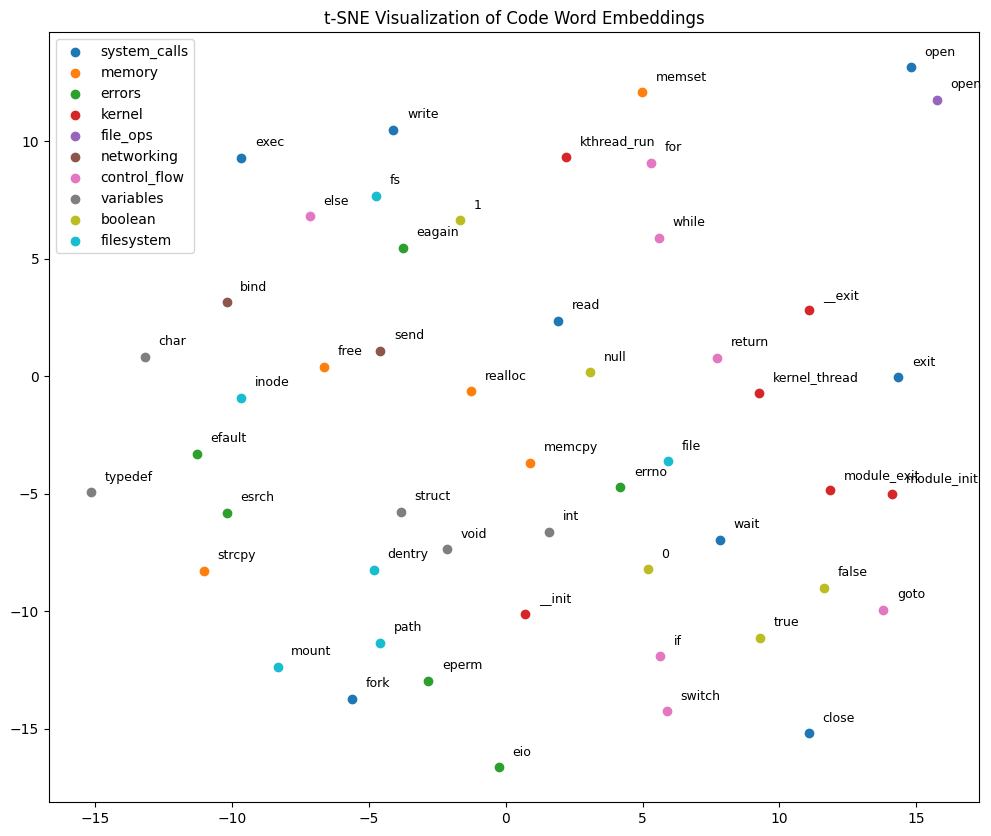

In [42]:
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=15, n_iter=1000, random_state=42)
X_2d = tsne.fit_transform(X_selected)

plt.figure(figsize=(12, 10))
start = 0
for group_name, words in word_groups.items():
    words_in_group = [w for w in words if w in linux_tokenizer.word_to_idx]
    n = len(words_in_group)
    end = start + n
    plt.scatter(X_2d[start:end, 0], X_2d[start:end, 1], label=group_name)
    for i, word in enumerate(words_in_group):
        plt.text(X_2d[start+i, 0]+0.5, X_2d[start+i, 1]+0.5, word, fontsize=9)
    start = end

plt.legend()
plt.title("t-SNE Visualization of Code Word Embeddings")
plt.show()
